In [21]:
import sys
import os
import pandas as pd
from pycox.models.cox import CoxPH
from torch.optim import AdamW
import torch
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test

%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
pp = Preprocessor()

In [23]:

df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [24]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [25]:
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data)
X, durations, events , scaler = Torch_preprocessing.get_data_set()

Genes before Treshold: 22
count    22.000000
mean      1.909091
std       6.625413
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      30.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 22


In [26]:
surival_data_set  =SurvivalDataSet(X, durations, events)
surival_data_set[0]

(tensor([ 0.2534,  0.9265,  0.7406,  0.5355, -0.5540,  0.4630,  0.2702, -0.7349,
          0.6199,  0.1077,  0.7869,  0.5109,  0.6553,  0.4475,  0.7873,  0.4932,
          0.1719, -0.0138, -0.0278]),
 tensor(43.4000),
 tensor(0.))

In [29]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

In [30]:
in_features = train_X.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1
output_bias = False

net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=num_nodes, out_features=out_features, batch_norm=batch_norm,
    dropout=dropout, output_bias=output_bias
)

In [31]:
model = CoxPH(net, tt.torchtuples.optim.Adam)

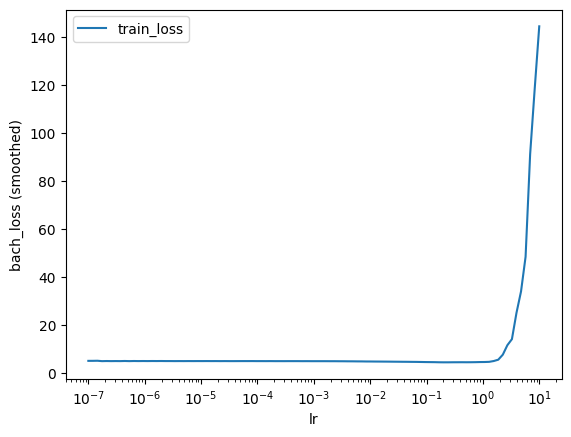

In [39]:
batch_size = 256
lrfinder = model.lr_finder(input=train_X, target=(train_durations,train_events), batch_size=batch_size)

_ = lrfinder.plot()

In [40]:
learning_rate = lrfinder.get_best_lr()

In [52]:
model.optimizer.set_lr(0.000001)

In [53]:
epochs = 200
callbacks = [tt.torchtuples.callbacks.EarlyStopping()]
verbose = True

In [54]:
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

35:	[0s / 0s],		train_loss: 3.8049,	val_loss: 3.2594
36:	[0s / 0s],		train_loss: 3.8315,	val_loss: 3.2721
37:	[0s / 0s],		train_loss: 3.8899,	val_loss: 3.2821
38:	[0s / 0s],		train_loss: 3.8736,	val_loss: 3.2796
39:	[0s / 0s],		train_loss: 3.8190,	val_loss: 3.2812
40:	[0s / 0s],		train_loss: 3.6691,	val_loss: 3.2810
41:	[0s / 0s],		train_loss: 3.7929,	val_loss: 3.2785
42:	[0s / 0s],		train_loss: 3.7228,	val_loss: 3.2817
43:	[0s / 0s],		train_loss: 3.8193,	val_loss: 3.2790
44:	[0s / 0s],		train_loss: 3.8419,	val_loss: 3.2854
45:	[0s / 0s],		train_loss: 3.6155,	val_loss: 3.2849


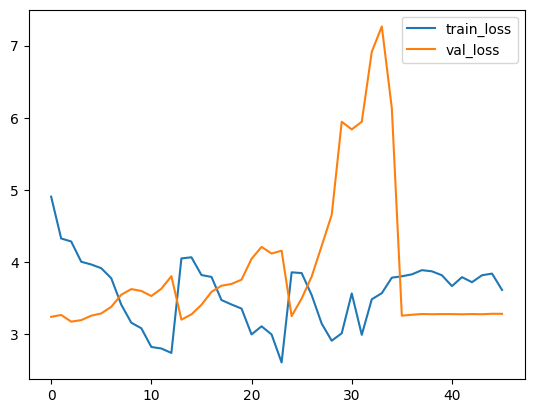

In [55]:
_ = log.plot()